# Telco Customer Churn Analysis & Prediction

##  Problem Statement:
Customer churn is a major challenge in the telecom industry.  
This project analyzes customer data to identify churn patterns and build a machine learning model to predict churn.

##  Objectives
- Perform Exploratory Data Analysis (EDA)
- Identify key factors influencing churn
- Build and evaluate ML models

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

# Drop missing values
df = df.dropna(subset=["TotalCharges"])

# Convert Churn to numeric
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Drop unnecessary column
df = df.drop(columns="customerID")

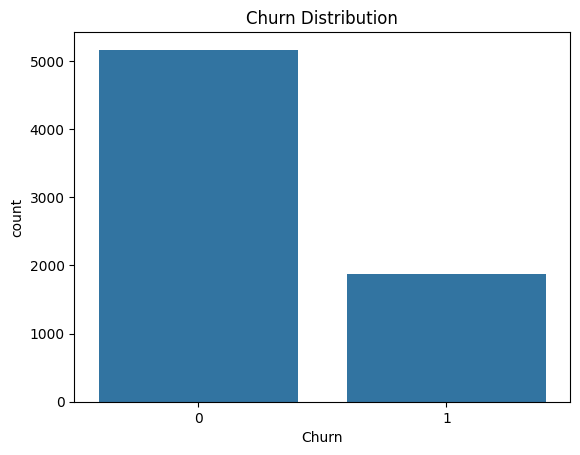

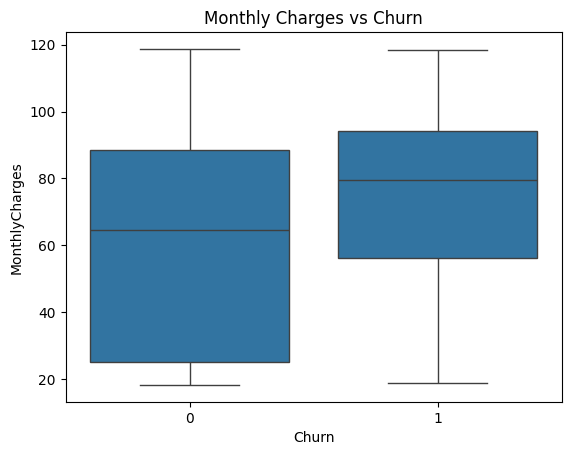

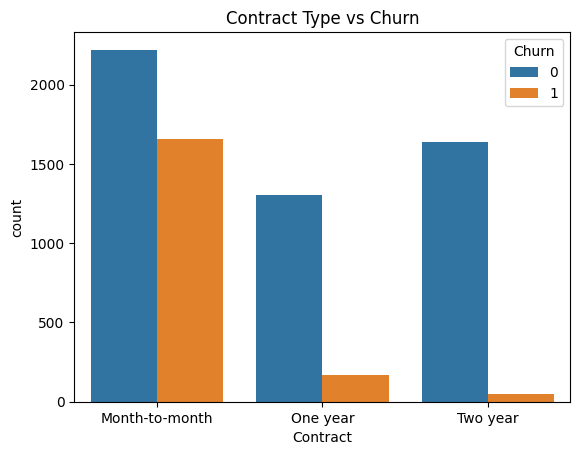

In [5]:
# Churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

# Contract vs Churn
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=360)
plt.show()

##  Key Insights:

- Customers with **month-to-month contracts** churn more frequently  
- Higher **monthly charges** are associated with higher churn  
- Customers with **longer tenure** are less likely to churn  

In [6]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [7]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Logistic Regression
lr = LogisticRegression(max_iter=3000, solver='saga')
lr.fit(X_train_scaled, y_train)

# Random Forest (NO scaling)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [10]:
# Logistic Regression
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

# Random Forest
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Logistic Regression
Accuracy: 0.8038379530916845
Confusion Matrix:
 [[916 117]
 [159 215]]
ROC-AUC: 0.8356313835927752

Random Forest
Accuracy: 0.7867803837953091
Confusion Matrix:
 [[917 116]
 [184 190]]
ROC-AUC: 0.8180808713523251


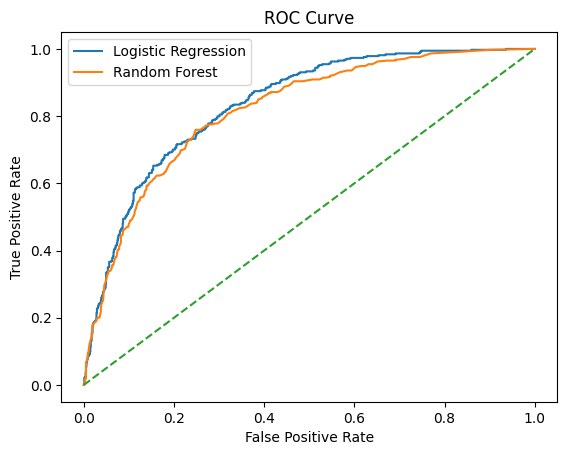

In [11]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

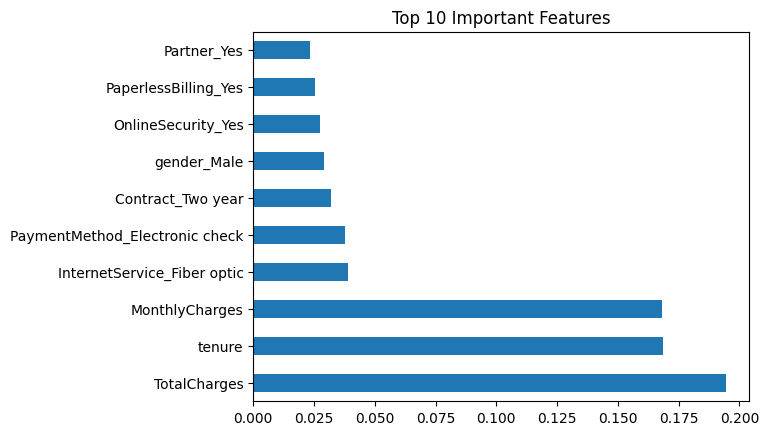

In [12]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [13]:
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_prob_lr >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred_t))


Threshold: 0.3
[[762 271]
 [ 90 284]]

Threshold: 0.4
[[846 187]
 [118 256]]

Threshold: 0.5
[[916 117]
 [159 215]]

Threshold: 0.6
[[965  68]
 [228 146]]


##  Conclusion

- Customers with **high monthly charges** and **short tenure** are more likely to churn  
- **Contract type** is one of the strongest predictors of churn  
- Random Forest performed slightly better in capturing complex patterns  

##  Business Recommendations

- Offer discounts to high-risk customers  
- Encourage long-term contracts  
- Target customers with high monthly charges for retention campaigns  